# Stage 06A — Development Event-Threshold Sensitivity

## tl;dr

This is a **development-only diagnostic**. It does not reopen, rerun, reinterpret, or replace the sealed Stage 05 independent result.

Across the 32 DIV2K calibration sources (229,376 patch rows), the original bad-detail event—centre-patch detail RMSE greater than 0.05—occurred **50,824 times (22.16%)** and was present in **all 32 sources**. Exploratory thresholds of 0.03 and 0.02 yield 43.50% and 59.83% positives, respectively. Therefore, the Stage 05 independent zero-event result cannot be explained simply by saying that 0.05 had no development support. It indicates a substantial development-to-independent event-support shift.

The design consequence is to retain the immutable Stage 05 conclusion, report threshold sensitivity as exploratory development evidence, and make future Stage 06 reliability evaluation severity-stratified and continuous as well as binary.


## Context & Methods

### Key assumptions

- Stage 05 remains immutable: H1 passed, H2 failed its locked 5% practical gate, and positive-event calibration at RMSE > 0.05 was not estimable on the independent cohort.
- Only DIV2K development sources 0869–0900 are loaded here.
- `detail_patch_error` is a patch detail **MSE**; thresholds are defined on RMSE, so `sqrt(detail_patch_error)` is compared with each tolerance.
- Patch rows are nested within sources. Uncertainty intervals therefore resample the 32 sources, never individual patches.
- Thresholds 0.025, 0.05, and 0.10 were named in the original pilot specification. Thresholds 0.02, 0.03, 0.04, and 0.075 are explicitly exploratory additions.


In [1]:
import hashlib
import io
import json
import os
import re
import zipfile
from pathlib import Path, PurePosixPath

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 20260925
BOOTSTRAP_REPLICATES = 10_000
THRESHOLDS = np.array([0.015, 0.020, 0.025, 0.030, 0.040, 0.050, 0.075, 0.100])
PREDECLARED_SENSITIVITY_THRESHOLDS = {0.025, 0.050, 0.100}
LOCKED_STAGE05_THRESHOLD = 0.050
EXPECTED_SOURCES = tuple(f"{value:04d}" for value in range(869, 901))
EXPECTED_CHAINS = (
    "q8_b16_n2",
    "j90_b16_n2",
    "j75_b16_n2",
    "j50_b16_n2",
    "j75_b12_n2",
    "j75_b20_n2",
    "j75_b16_n5",
)

IN_COLAB = False
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = Path(os.environ.get(
        "STAGE06_PROJECT_DIR",
        "/content/drive/MyDrive/reliable-reconstruction-under-mismatch",
    ))
else:
    PROJECT_DIR = Path(os.environ.get("STAGE06_PROJECT_DIR", Path.cwd()))

ARCHIVE_DIR_TEXT = ""  # @param {type:"string"}
if ARCHIVE_DIR_TEXT.strip():
    ARCHIVE_DIR = Path(ARCHIVE_DIR_TEXT)
else:
    candidates = [
        Path(os.environ.get("STAGE05_ARCHIVE_DIR", "")),
        PROJECT_DIR / "results",
        PROJECT_DIR.parent / "stage06_inputs" / "Imaging_Project",
        Path.cwd() / "stage06_inputs" / "Imaging_Project",
    ]
    ARCHIVE_DIR = next((p for p in candidates if str(p) and p.is_dir()), candidates[1])

OUTPUT_DIR = PROJECT_DIR / "results" / "stage06a_development_threshold_sensitivity"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": "#444444",
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.7,
})

print("Project directory:", PROJECT_DIR)
print("Archive directory:", ARCHIVE_DIR)
print("Output directory:", OUTPUT_DIR)


Project directory: /workspace/scratch/af6f5594d86c/stage06_repo
Archive directory: /workspace/scratch/af6f5594d86c/stage06_inputs/Imaging_Project
Output directory: /workspace/scratch/af6f5594d86c/stage06_repo/results/stage06a_development_threshold_sensitivity


## Data

### 1. Resolve and verify the frozen development archives

Only shard indices 08–11 are admissible because they contain calibration sources 0869–0900. Duplicate shard indices, missing manifests, failed hashes, unexpected roots, or out-of-partition source IDs stop execution.


In [2]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def verify_archive_manifest(path: Path, expected_root: str | None) -> dict:
    with zipfile.ZipFile(path) as archive:
        names = archive.namelist()
        if expected_root is None:
            manifest_name = "export_manifest.json"
        else:
            manifest_name = f"{expected_root}/export_manifest.json"
            roots = {name.split("/", 1)[0] for name in names if "/" in name}
            assert roots == {expected_root}, (path.name, roots)
        assert manifest_name in names, f"Missing manifest in {path.name}"
        manifest = json.loads(archive.read(manifest_name))
        verified = 0
        for row in manifest["files"]:
            member = row["path"] if expected_root is None else f"{expected_root}/{row['path']}"
            payload = archive.read(member)
            assert len(payload) == int(row["byte_count"]), member
            assert hashlib.sha256(payload).hexdigest() == row["sha256"], member
            verified += 1
    return {
        "archive": path.name,
        "archive_sha256": sha256_file(path),
        "manifest_files_verified": verified,
    }


all_shard_candidates = sorted(ARCHIVE_DIR.glob("independent_05c_development_shard_*_of_12*.zip"))
by_index = {}
for path in all_shard_candidates:
    match = re.search(r"shard_(\d{2})_of_12", path.name)
    if match:
        by_index.setdefault(int(match.group(1)), []).append(path)

required_indices = (8, 9, 10, 11)
for index in required_indices:
    assert index in by_index, f"Missing development shard {index:02d} in {ARCHIVE_DIR}"
    assert len(by_index[index]) == 1, f"Expected one ZIP for shard {index:02d}: {by_index[index]}"
SHARD_ARCHIVES = [by_index[index][0] for index in required_indices]

c2_candidates = sorted(ARCHIVE_DIR.glob("independent_05c2_development_reliability_*.zip"))
assert len(c2_candidates) == 1, f"Expected exactly one Stage 05C2 archive: {c2_candidates}"
C2_ARCHIVE = c2_candidates[0]

verification_rows = []
for index, path in zip(required_indices, SHARD_ARCHIVES):
    root = f"independent_05c_development_shard_{index:02d}_of_12"
    verification_rows.append(verify_archive_manifest(path, root))
verification_rows.append(verify_archive_manifest(C2_ARCHIVE, None))
verification = pd.DataFrame(verification_rows)
verification


,archive,archive_sha256,manifest_files_verified
0,independent_05c_development_shard_08_of_12-202...,ad5224d814e094377b8c85b657b287ba1a936b5d7034a3...,124
1,independent_05c_development_shard_09_of_12-202...,dea528681ac602bdb2485ac0fa96aac0f86d1b08f92c85...,124
2,independent_05c_development_shard_10_of_12-202...,44418f8f5b3ca3a8163b2d7f62c5c1a5fe1fa5a8b73d20...,124
3,independent_05c_development_shard_11_of_12-202...,6e1cfebfe5a140b8dbfa78d3b2004ac0b8eb21e6732e9f...,124
4,independent_05c2_development_reliability_20260...,a77f409016070ac799133502c3b24f9603e918b85a3069...,27


### 2. Load continuous patch-detail errors

Every compact observation must contain exactly 1,024 patches. The stored Stage 05 target is independently reconstructed as `RMSE > 0.05` and checked patch-for-patch.


In [3]:
observation_rows = []
for shard_path in SHARD_ARCHIVES:
    with zipfile.ZipFile(shard_path) as archive:
        compact_names = sorted(
            name for name in archive.namelist()
            if "/compact/" in name and name.endswith(".npz")
        )
        assert len(compact_names) == 8 * 7, (shard_path.name, len(compact_names))
        for member in compact_names:
            stem = PurePosixPath(member).stem
            source_id, chain_id = stem.split("_", 1)
            assert source_id in EXPECTED_SOURCES
            assert chain_id in EXPECTED_CHAINS
            with np.load(io.BytesIO(archive.read(member)), allow_pickle=False) as stored:
                patch_mse = stored["detail_patch_error"].astype(np.float64)
                frozen_target = stored["target_bad_detail_0p05"].astype(np.uint8)
            assert patch_mse.shape == (1024,)
            assert np.isfinite(patch_mse).all() and (patch_mse >= 0).all()
            patch_rmse = np.sqrt(patch_mse)
            reconstructed_target = (patch_rmse > LOCKED_STAGE05_THRESHOLD).astype(np.uint8)
            assert np.array_equal(frozen_target, reconstructed_target), stem
            for patch_index, rmse in enumerate(patch_rmse):
                observation_rows.append((source_id, chain_id, patch_index, float(rmse)))

patches = pd.DataFrame(
    observation_rows,
    columns=["source_id", "chain_id", "patch_index", "detail_rmse"],
)
assert len(patches) == 32 * 7 * 1024
assert tuple(sorted(patches.source_id.unique())) == EXPECTED_SOURCES
assert set(patches.chain_id.unique()) == set(EXPECTED_CHAINS)
assert not patches.duplicated(["source_id", "chain_id", "patch_index"]).any()

with zipfile.ZipFile(C2_ARCHIVE) as archive:
    with np.load(io.BytesIO(archive.read("calibration_predictions.npz")), allow_pickle=False) as stored:
        c2_target = stored["target_bad_detail_0p05"].astype(np.uint8)
assert int(c2_target.sum()) == int((patches.detail_rmse > 0.05).sum())
assert len(c2_target) == len(patches)

patches.describe(percentiles=[0.5, 0.9, 0.95, 0.99])


,patch_index,detail_rmse
count,229376.000000,229376.000000
mean,511.500000,0.031767
std,295.603841,0.024120
min,0.000000,0.000003
50%,511.500000,0.025841
90%,921.000000,0.066062
95%,972.000000,0.077886
99%,1013.000000,0.101671
max,1023.000000,0.171319


## Results

### 3. Event support across candidate thresholds

The table reports patch counts, source-macro prevalence, and a 95% percentile bootstrap interval obtained by resampling the 32 sources as clusters.


In [4]:
rng = np.random.default_rng(SEED)
sources = np.array(EXPECTED_SOURCES)
source_threshold = []
for threshold in THRESHOLDS:
    source_rates = (
        patches.assign(event=patches.detail_rmse.gt(threshold))
        .groupby("source_id", sort=True).event.mean()
        .reindex(EXPECTED_SOURCES)
    )
    sampled_indices = rng.integers(0, len(sources), size=(BOOTSTRAP_REPLICATES, len(sources)))
    boot = source_rates.to_numpy()[sampled_indices].mean(axis=1)
    positive_sources = (
        patches.assign(event=patches.detail_rmse.gt(threshold))
        .groupby("source_id").event.any().sum()
    )
    positives = int(patches.detail_rmse.gt(threshold).sum())
    source_threshold.append({
        "threshold_rmse": float(threshold),
        "threshold_origin": (
            "locked Stage 05 target" if np.isclose(threshold, 0.05)
            else "predeclared pilot sensitivity" if float(threshold) in PREDECLARED_SENSITIVITY_THRESHOLDS
            else "Stage 06A exploratory"
        ),
        "patch_rows": int(len(patches)),
        "positive_patches": positives,
        "patch_prevalence": positives / len(patches),
        "source_macro_prevalence": float(source_rates.mean()),
        "source_bootstrap_ci_low": float(np.quantile(boot, 0.025)),
        "source_bootstrap_ci_high": float(np.quantile(boot, 0.975)),
        "sources_with_positive_event": int(positive_sources),
        "source_count": len(sources),
    })

threshold_summary = pd.DataFrame(source_threshold)
threshold_summary.style.format({
    "threshold_rmse": "{:.3f}",
    "patch_prevalence": "{:.2%}",
    "source_macro_prevalence": "{:.2%}",
    "source_bootstrap_ci_low": "{:.2%}",
    "source_bootstrap_ci_high": "{:.2%}",
})


,threshold_rmse,threshold_origin,patch_rows,positive_patches,patch_prevalence,source_macro_prevalence,source_bootstrap_ci_low,source_bootstrap_ci_high,sources_with_positive_event,source_count
0,0.015,Stage 06A exploratory,229376,157725,68.76%,68.76%,59.68%,77.48%,32,32
1,0.020,Stage 06A exploratory,229376,137231,59.83%,59.83%,49.99%,69.26%,32,32
2,0.025,predeclared pilot sensitivity,229376,117803,51.36%,51.36%,41.27%,60.88%,32,32
3,0.030,Stage 06A exploratory,229376,99778,43.50%,43.50%,33.34%,53.56%,32,32
4,0.040,Stage 06A exploratory,229376,72338,31.54%,31.54%,22.56%,40.89%,32,32
5,0.050,locked Stage 05 target,229376,50824,22.16%,22.16%,14.83%,29.81%,32,32
6,0.075,Stage 06A exploratory,229376,13555,5.91%,5.91%,3.41%,8.80%,27,32
7,0.100,predeclared pilot sensitivity,229376,2605,1.14%,1.14%,0.42%,2.10%,20,32


In [5]:
chain_rows = []
source_rows = []
for threshold in THRESHOLDS:
    tagged = patches.assign(event=patches.detail_rmse.gt(threshold))
    for chain_id, frame in tagged.groupby("chain_id", sort=True):
        chain_rows.append({
            "threshold_rmse": float(threshold),
            "chain_id": chain_id,
            "patch_rows": len(frame),
            "positive_patches": int(frame.event.sum()),
            "patch_prevalence": float(frame.event.mean()),
            "sources_with_positive_event": int(frame.groupby("source_id").event.any().sum()),
        })
    for source_id, frame in tagged.groupby("source_id", sort=True):
        source_rows.append({
            "threshold_rmse": float(threshold),
            "source_id": source_id,
            "patch_rows": len(frame),
            "positive_patches": int(frame.event.sum()),
            "prevalence": float(frame.event.mean()),
        })

chain_summary = pd.DataFrame(chain_rows)
source_summary = pd.DataFrame(source_rows)
chain_summary.query("threshold_rmse in [0.02, 0.03, 0.05]").pivot(
    index="chain_id", columns="threshold_rmse", values="patch_prevalence"
).style.format("{:.2%}")


threshold_rmse,0.020000,0.030000,0.050000
chain_id,,,
j50_b16_n2,60.69%,44.77%,23.33%
j75_b12_n2,53.72%,35.67%,15.01%
j75_b16_n2,60.18%,44.17%,22.90%
j75_b16_n5,62.27%,45.39%,23.10%
j75_b20_n2,62.44%,47.27%,25.67%
j90_b16_n2,59.81%,43.70%,22.61%
q8_b16_n2,59.68%,43.53%,22.48%


### 4. Visual diagnostics

The first chart shows the source-macro prevalence curve with source-bootstrap intervals. The second exposes whether support is confined to particular acquisition chains. The third shows between-source heterogeneity rather than treating patches as independent replicates.


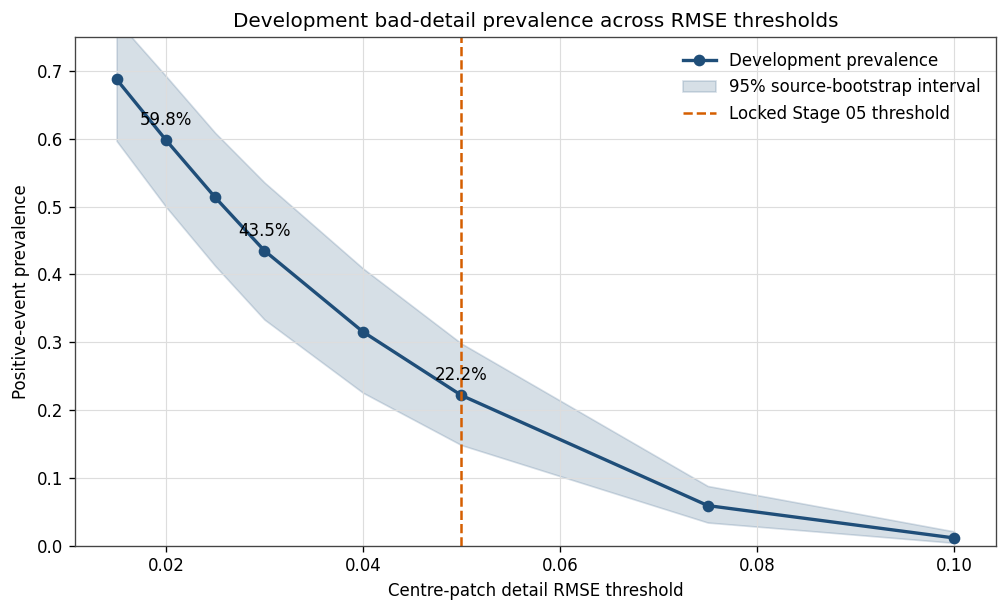

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
x = threshold_summary.threshold_rmse.to_numpy()
y = threshold_summary.source_macro_prevalence.to_numpy()
lo = threshold_summary.source_bootstrap_ci_low.to_numpy()
hi = threshold_summary.source_bootstrap_ci_high.to_numpy()
ax.plot(x, y, color="#1f4e79", marker="o", linewidth=2, label="Development prevalence")
ax.fill_between(x, lo, hi, color="#1f4e79", alpha=0.18, label="95% source-bootstrap interval")
ax.axvline(0.05, color="#d55e00", linestyle="--", linewidth=1.5, label="Locked Stage 05 threshold")
for threshold in (0.02, 0.03, 0.05):
    row = threshold_summary[np.isclose(threshold_summary.threshold_rmse, threshold)].iloc[0]
    ax.annotate(
        f"{row.source_macro_prevalence:.1%}",
        (threshold, row.source_macro_prevalence),
        xytext=(0, 9), textcoords="offset points", ha="center",
    )
ax.set(title="Development bad-detail prevalence across RMSE thresholds",
       xlabel="Centre-patch detail RMSE threshold", ylabel="Positive-event prevalence")
ax.set_ylim(0, 0.75)
ax.legend(frameon=False)
fig.tight_layout()
prevalence_path = OUTPUT_DIR / "development_event_prevalence_curve.png"
fig.savefig(prevalence_path)
plt.show()


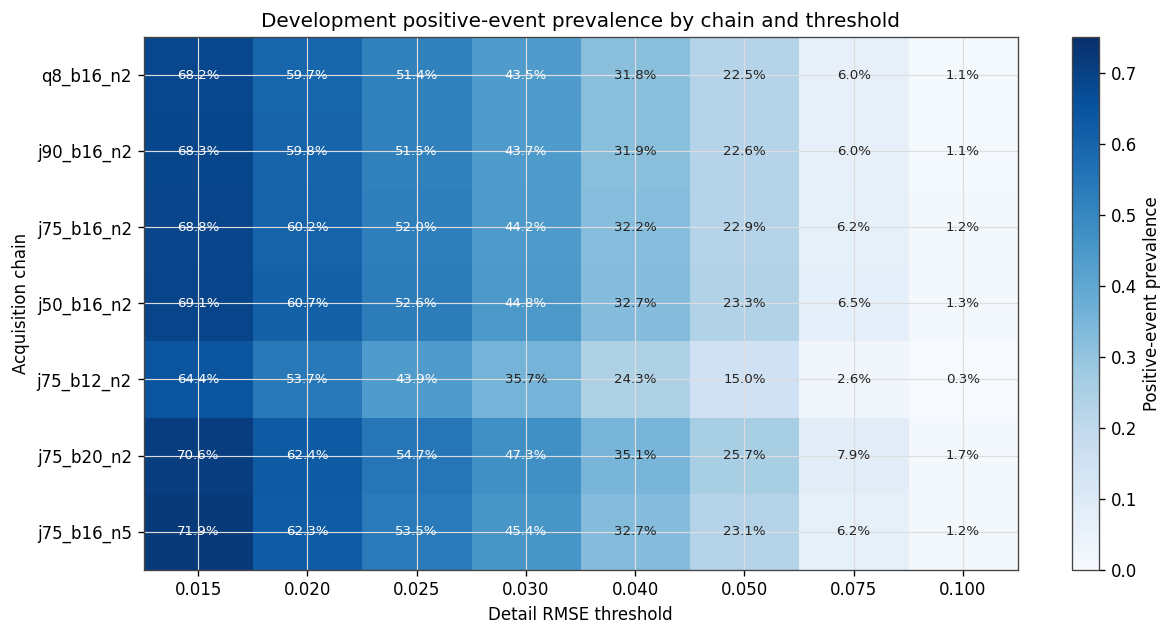

In [7]:
heat = chain_summary.pivot(index="chain_id", columns="threshold_rmse", values="patch_prevalence")
heat = heat.reindex(EXPECTED_CHAINS)
fig, ax = plt.subplots(figsize=(10.5, 5.4))
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=0.75)
ax.set_xticks(range(len(heat.columns)), [f"{v:.3f}" for v in heat.columns])
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xlabel("Detail RMSE threshold")
ax.set_ylabel("Acquisition chain")
ax.set_title("Development positive-event prevalence by chain and threshold")
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        value = heat.iloc[i, j]
        ax.text(j, i, f"{value:.1%}", ha="center", va="center",
                color="white" if value > 0.42 else "#222222", fontsize=8)
fig.colorbar(im, ax=ax, label="Positive-event prevalence")
fig.tight_layout()
heatmap_path = OUTPUT_DIR / "development_chain_threshold_heatmap.png"
fig.savefig(heatmap_path)
plt.show()


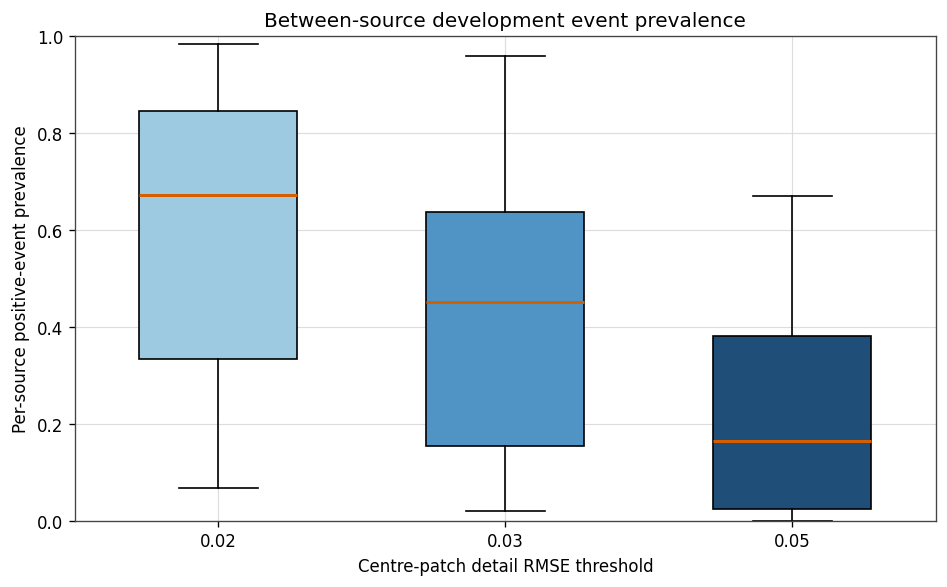

In [8]:
chosen = source_summary[source_summary.threshold_rmse.isin([0.02, 0.03, 0.05])]
groups = [chosen.loc[np.isclose(chosen.threshold_rmse, t), "prevalence"].to_numpy() for t in (0.02, 0.03, 0.05)]
fig, ax = plt.subplots(figsize=(8.0, 5.0))
bp = ax.boxplot(groups, tick_labels=["0.02", "0.03", "0.05"], patch_artist=True, widths=0.55)
colors = ["#9ecae1", "#4f94c4", "#1f4e79"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
for median in bp["medians"]:
    median.set_color("#d55e00")
    median.set_linewidth(1.8)
ax.set(title="Between-source development event prevalence",
       xlabel="Centre-patch detail RMSE threshold", ylabel="Per-source positive-event prevalence")
ax.set_ylim(0, 1)
fig.tight_layout()
source_path = OUTPUT_DIR / "development_source_prevalence_distribution.png"
fig.savefig(source_path)
plt.show()


## Takeaways

1. **The locked 0.05 target had substantial development support.** It was positive for 50,824/229,376 development calibration patches (22.16%) and occurred in all 32 calibration sources.
2. **Lower thresholds do not merely repair sparsity.** RMSE thresholds 0.03 and 0.02 label 43.50% and 59.83% of development patches as failures. Their operational meaning would need justification before reuse.
3. **The Stage 05 failure is a transfer problem.** Moving from 22.16% development prevalence to zero independent positives is evidence of event-support shift; it is not evidence that the independent failure probability is universally zero.
4. **Stage 05 remains unchanged.** No alternative threshold reported here can rescue or replace the sealed RMSE > 0.05 calibration result.
5. **Stage 06 should not depend on one binary threshold.** The next protocol will combine continuous RMSE calibration, severity strata, a development-frozen operational event, and an event-support gate before independent unsealing.


## Export and audit record

Compact CSV/JSON results and publication-ready figures are exported with SHA-256 receipts. Raw development arrays and model checkpoints are not duplicated.


In [9]:
threshold_summary.to_csv(OUTPUT_DIR / "threshold_summary.csv", index=False)
chain_summary.to_csv(OUTPUT_DIR / "chain_threshold_summary.csv", index=False)
source_summary.to_csv(OUTPUT_DIR / "source_threshold_summary.csv", index=False)
verification.to_csv(OUTPUT_DIR / "input_archive_verification.csv", index=False)

locked = threshold_summary[np.isclose(threshold_summary.threshold_rmse, 0.05)].iloc[0]
summary = {
    "stage": "06A_development_event_threshold_sensitivity",
    "role": "development_only_post_stage05_diagnostic",
    "stage05_evidence_modified": False,
    "development_sources": 32,
    "development_patch_rows": int(len(patches)),
    "locked_stage05_threshold_rmse": 0.05,
    "locked_threshold_positive_patches": int(locked.positive_patches),
    "locked_threshold_prevalence": float(locked.patch_prevalence),
    "locked_threshold_sources_with_positive_event": int(locked.sources_with_positive_event),
    "interpretation": (
        "The 0.05 event had substantial development support; its absence in the Stage 05 "
        "independent cohort represents event-support shift, not permission to relabel Stage 05."
    ),
    "thresholds": THRESHOLDS.tolist(),
}
(OUTPUT_DIR / "summary.json").write_text(json.dumps(summary, indent=2) + "\n", encoding="utf-8")

export_files = [
    "threshold_summary.csv",
    "chain_threshold_summary.csv",
    "source_threshold_summary.csv",
    "input_archive_verification.csv",
    "summary.json",
    "development_event_prevalence_curve.png",
    "development_chain_threshold_heatmap.png",
    "development_source_prevalence_distribution.png",
]
manifest = []
for name in export_files:
    path = OUTPUT_DIR / name
    manifest.append({
        "path": name,
        "byte_count": path.stat().st_size,
        "sha256": sha256_file(path),
    })
(OUTPUT_DIR / "export_manifest.json").write_text(
    json.dumps({
        "stage": "06A_development_event_threshold_sensitivity",
        "development_only": True,
        "stage05_evidence_modified": False,
        "files": manifest,
    }, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(summary, indent=2))
print("Exported:", OUTPUT_DIR)


{
  "stage": "06A_development_event_threshold_sensitivity",
  "role": "development_only_post_stage05_diagnostic",
  "stage05_evidence_modified": false,
  "development_sources": 32,
  "development_patch_rows": 229376,
  "locked_stage05_threshold_rmse": 0.05,
  "locked_threshold_positive_patches": 50824,
  "locked_threshold_prevalence": 0.22157505580357142,
  "locked_threshold_sources_with_positive_event": 32,
  "interpretation": "The 0.05 event had substantial development support; its absence in the Stage 05 independent cohort represents event-support shift, not permission to relabel Stage 05.",
  "thresholds": [
    0.015,
    0.02,
    0.025,
    0.03,
    0.04,
    0.05,
    0.075,
    0.1
  ]
}
Exported: /workspace/scratch/af6f5594d86c/stage06_repo/results/stage06a_development_threshold_sensitivity
